In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
from sklearn import datasets
from sklearn import svm
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.tree import export_graphviz
from IPython.display import Image


In [ ]:
#df_train = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_300m_v15.txt', header=None)
#df_test = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_156m_test_V15.txt', header=None) #156m
df_Conjunt = pd.read_csv('/content/Train_Test_Normalitzat_Conjunt_V2.txt',header=None)

In [ ]:

df_train, df_test = train_test_split(df_Conjunt, test_size=0.80, random_state=20)

FE_Train = df_train.iloc[:, 0:7]
Etiqueta_Train = df_train.iloc[:, 7]

FE_Test = df_test.iloc[:, 0:7]
Etiqueta_Test = df_test.iloc[:, 7]

# Verificación opcional del tamaño
print(f"Tamany Total: {len(df_Conjunt)}")
print(f"Tamany Train: {len(df_train)} | Tamany Test: {len(df_test)}")

Registros totales: 2553
Registros Train: 510 | Registros Test: 2043


In [ ]:
#FE_Train = df_train.iloc[:, 0:7]
#Etiqueta_Train = df_train.iloc[:, 7]
#FE_Test = df_test.iloc[:, 0:7]
#Etiqueta_Test = df_test.iloc[:, 7]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    random_state=4,
    n_jobs=-1
)


In [ ]:
rf_model.fit(FE_Train, Etiqueta_Train)
y_pred = rf_model.predict(FE_Test)

In [ ]:
print(f"Precisió Global: {accuracy_score(Etiqueta_Test, y_pred)}")
print(classification_report(Etiqueta_Test, y_pred))

Precisión Global: 0.8252569750367107
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       674
           1       0.77      0.90      0.83       681
           2       0.84      0.70      0.76       688

    accuracy                           0.83      2043
   macro avg       0.83      0.83      0.82      2043
weighted avg       0.83      0.83      0.82      2043



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn import metrics

# Usamos 'average' para manejar los 3 movimientos
accuracy = accuracy_score(Etiqueta_Test, y_pred)
precision = precision_score(Etiqueta_Test, y_pred, average='weighted')
recall = recall_score(Etiqueta_Test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precisió: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("F1-Score:", metrics.f1_score(Etiqueta_Test, y_pred, average='weighted'))

Accuracy (Precisión Global): 0.825
Precision (Calidad de la predicción): 0.829
Recall (Capacidad de detección): 0.825
F1-Score: 0.823199769922786


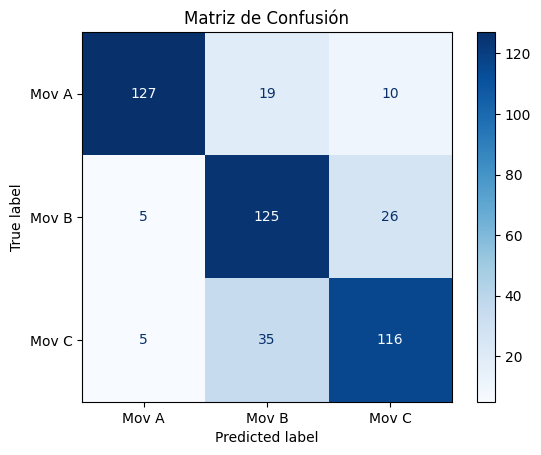

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(Etiqueta_Test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriu de Confusió")
plt.show()

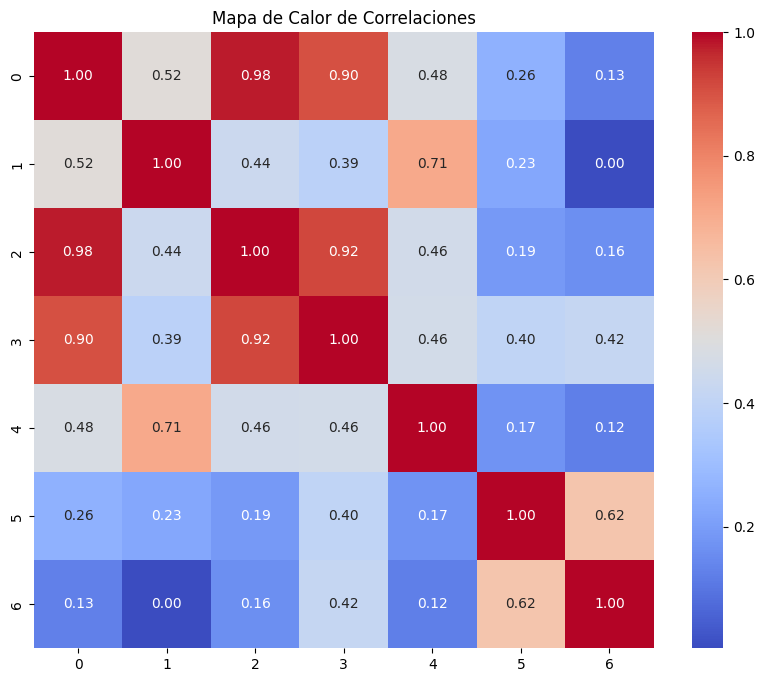

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ahora ya no dará NameError
plt.figure(figsize=(10, 8))
correlation_matrix = FE_Train.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa Correlació")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Esto entrena y prueba el modelo 5 veces con diferentes pedazos de tus datos
scores = cross_val_score(rf_model, FE_Train, Etiqueta_Train, cv=5)
print(f"Presició mitja: {scores.mean()} (+/- {scores.std() * 2})")

Presició mitja: 0.8352941176470589 (+/- 0.06371794827165465)


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 15, None],
    'min_samples_split': [2, 5, 10, 15]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid_search.fit(FE_Train, Etiqueta_Train)

print(f"Millors paràmetres: {grid_search.best_params_}")

Mejores parámetros: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 50}
